<a href="https://colab.research.google.com/github/moulikagurram83/bapatla-salinity-mapping/blob/main/DataCollection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Install all libraries you need for the entire project ──
!pip install earthengine-api geemap rasterio geopandas \
             numpy pandas scikit-learn matplotlib torch \
             torch-geometric requests

# ── Authenticate GEE (opens a browser tab — paste the token back) ──
import ee
ee.Authenticate()
ee.Initialize(project='ornate-chemist-460504-m0')   # replace with your GEE project ID

print("GEE connected ✓")

GEE connected ✓


In [ ]:
# Accurate polygon following Bapatla district boundary
# Covers all 25 mandals including coastal belt up to Bay of Bengal
study_area = ee.Geometry.Polygon([[
    [79.80, 15.40],   # SW corner — Prakasam border
    [80.10, 15.40],   # S — Chirala coastal belt
    [80.45, 15.50],   # SE — Suryalanka beach area
    [80.75, 15.70],   # E — Krishna delta border
    [80.70, 16.00],   # NE — towards Krishna district
    [80.50, 16.30],   # N — Guntur border
    [80.10, 16.20],   # NW — Tenali division side
    [79.80, 16.00],   # W — Palnadu border
    [79.80, 15.40]    # close polygon
]])

print("Bapatla district polygon set ✓")

Bapatla district polygon set ✓


In [ ]:
import geemap

Map = geemap.Map()
Map.centerObject(study_area, 10)
Map.addLayer(study_area, {'color': 'red'}, 'Bapatla District')

# Add satellite basemap
Map.add_basemap('SATELLITE')
Map

Map(center=[15.824511724369222, 80.2421187163748], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
import ee

# Direct polygon — no dependency on FAO dataset
study_area = ee.Geometry.Polygon([[
    [80.00, 15.45],
    [80.25, 15.45],
    [80.55, 15.55],
    [80.75, 15.75],
    [80.70, 16.10],
    [80.45, 16.25],
    [80.10, 16.20],
    [79.90, 16.00],
    [79.85, 15.70],
    [80.00, 15.45]
]])

print("Study area defined ✓")
print("Area (sq km):", round(study_area.area().getInfo() / 1e6, 1))
# Should print roughly 3500–4000 sq km

Study area defined ✓
Area (sq km): 6571.9


In [ ]:
import geemap

Map = geemap.Map(center=[15.90, 80.46], zoom=10)  # Force center on Bapatla town

# Add the boundary with thick visible style
Map.addLayer(
    study_area,
    {'color': 'FF0000', 'fillColor': 'FF000033', 'width': 3},
    'Bapatla District'
)

# Add a point marker at Bapatla town center
bapatla_point = ee.Geometry.Point([80.4674, 15.9042])
Map.addLayer(bapatla_point, {'color': 'blue'}, 'Bapatla Town')

Map.add_basemap('SATELLITE')
Map

Map(center=[15.9, 80.46], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [ ]:
# Print the coordinates back to verify
coords = study_area.bounds().getInfo()
print("Bounding box:", coords['coordinates'])

# Count available Sentinel-2 images in this area
s2_count = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(study_area)
            .filterDate('2023-01-01', '2023-12-31')
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
            .size().getInfo())

print(f"Sentinel-2 images available (2023): {s2_count}")
# Should print a number > 0 — confirms data exists for your area

Bounding box: [[[79.85, 15.449999999999974], [80.75, 15.449999999999974], [80.75, 16.250000000000025], [79.85, 16.250000000000025], [79.85, 15.449999999999974]]]
Sentinel-2 images available (2023): 160


In [ ]:
import ee

def compute_indices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndsi = image.normalizedDifference(['B3', 'B11']).rename('NDSI')

    aster_si = image.expression(
        'sqrt(GREEN * RED)', {
            'GREEN': image.select('B3'),
            'RED':   image.select('B4')
        }
    ).rename('ASTER_SI')

    si1 = image.normalizedDifference(['B11', 'B8']).rename('SI1')

    si2 = image.expression(
        'sqrt(RED * GREEN)', {
            'RED':   image.select('B4'),
            'GREEN': image.select('B3')
        }
    ).rename('SI2')

    return image.addBands([ndvi, ndsi, aster_si, si1, si2])

print("Index functions defined ✓")

Index functions defined ✓


In [ ]:
s2_years = list(range(2010, 2025))  # 8 years
s2_composites = []

for year in s2_years:
    comp = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(study_area)
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
        .map(compute_indices)
        .median()
        .select(['NDVI', 'NDSI', 'ASTER_SI', 'SI1', 'SI2'])
        .clip(study_area)
    )

    # Rename bands to include year: NDVI_2017, NDSI_2017 ...
    band_names = ['NDVI', 'NDSI', 'ASTER_SI', 'SI1', 'SI2']
    new_names  = [f'{b}_{year}' for b in band_names]
    comp = comp.rename(new_names)

    s2_composites.append(comp)
    print(f"  {year} ✓")

print("\nAll Sentinel-2 composites ready ✓")

  2010 ✓
  2011 ✓
  2012 ✓
  2013 ✓
  2014 ✓
  2015 ✓
  2016 ✓
  2017 ✓
  2018 ✓
  2019 ✓
  2020 ✓
  2021 ✓
  2022 ✓
  2023 ✓
  2024 ✓

All Sentinel-2 composites ready ✓


In [ ]:
def compute_landsat_indices(image):
    ndvi    = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    ndsi    = image.normalizedDifference(['SR_B3', 'SR_B6']).rename('NDSI')
    aster   = image.expression('sqrt(GREEN * RED)', {
                  'GREEN': image.select('SR_B3'),
                  'RED':   image.select('SR_B4')
              }).rename('ASTER_SI')
    si1     = image.normalizedDifference(['SR_B6', 'SR_B5']).rename('SI1')
    si2     = image.expression('sqrt(RED * GREEN)', {
                  'RED':   image.select('SR_B4'),
                  'GREEN': image.select('SR_B3')
              }).rename('SI2')
    return image.addBands([ndvi, ndsi, aster, si1, si2])

ls_years = list(range(2010, 2025))  # 4 years
ls_composites = []

for year in ls_years:
    comp = (
        ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
        .filterBounds(study_area)
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .filter(ee.Filter.lt('CLOUD_COVER', 10))
        .map(compute_landsat_indices)
        .median()
        .select(['NDVI', 'NDSI', 'ASTER_SI', 'SI1', 'SI2'])
        .clip(study_area)
    )

    new_names = [f'{b}_{year}' for b in ['NDVI','NDSI','ASTER_SI','SI1','SI2']]
    comp = comp.rename(new_names)
    ls_composites.append(comp)
    print(f"  {year} ✓")

print("\nAll Landsat composites ready ✓")

  2010 ✓
  2011 ✓
  2012 ✓
  2013 ✓
  2014 ✓
  2015 ✓
  2016 ✓
  2017 ✓
  2018 ✓
  2019 ✓
  2020 ✓
  2021 ✓
  2022 ✓
  2023 ✓
  2024 ✓

All Landsat composites ready ✓


In [ ]:
def safe_s2_composite(year, study_area):
    """Get composite — relaxes cloud filter if not enough images found."""

    for cloud_thresh in [10, 20, 30, 50]:  # progressively relax threshold
        col = (
            ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(study_area)
            .filterDate(f'{year}-01-01', f'{year}-12-31')
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_thresh))
            .map(compute_indices)
        )
        count = col.size().getInfo()
        if count > 0:
            print(f"  {year} ✓  ({count} images, cloud<{cloud_thresh}%)")
            comp = col.median().select(['NDVI','NDSI','ASTER_SI','SI1','SI2']).clip(study_area)
            new_names = [f'{b}_{year}' for b in ['NDVI','NDSI','ASTER_SI','SI1','SI2']]
            return comp.rename(new_names)

    # Last resort — use all images with no cloud filter
    print(f"  {year} ⚠ using all images (no cloud filter)")
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(study_area)
           .filterDate(f'{year}-01-01', f'{year}-12-31')
           .map(compute_indices))
    comp = col.median().select(['NDVI','NDSI','ASTER_SI','SI1','SI2']).clip(study_area)
    new_names = [f'{b}_{year}' for b in ['NDVI','NDSI','ASTER_SI','SI1','SI2']]
    return comp.rename(new_names)


s2_years = list(range(2010, 2025))
s2_composites = []

print("Building Sentinel-2 composites...")
for year in s2_years:
    comp = safe_s2_composite(year, study_area)
    s2_composites.append(comp)

print("\nAll Sentinel-2 composites ready ✓")

Building Sentinel-2 composites...
  2010 ⚠ using all images (no cloud filter)
  2011 ⚠ using all images (no cloud filter)
  2012 ⚠ using all images (no cloud filter)
  2013 ⚠ using all images (no cloud filter)
  2014 ⚠ using all images (no cloud filter)
  2015 ✓  (1 images, cloud<10%)
  2016 ✓  (16 images, cloud<10%)
  2017 ✓  (25 images, cloud<10%)
  2018 ✓  (43 images, cloud<10%)
  2019 ✓  (200 images, cloud<10%)
  2020 ✓  (166 images, cloud<10%)
  2021 ✓  (170 images, cloud<10%)
  2022 ✓  (139 images, cloud<10%)
  2023 ✓  (160 images, cloud<10%)
  2024 ✓  (113 images, cloud<10%)

All Sentinel-2 composites ready ✓


In [ ]:
import ee

# ── Index functions ──────────────────────────────────────────
def compute_s2_indices(image):
    ndvi    = image.normalizedDifference(['B8','B4']).rename('NDVI')
    ndsi    = image.normalizedDifference(['B3','B11']).rename('NDSI')
    aster   = image.expression('sqrt(GREEN*RED)',{'GREEN':image.select('B3'),'RED':image.select('B4')}).rename('ASTER_SI')
    si1     = image.normalizedDifference(['B11','B8']).rename('SI1')
    si2     = image.expression('sqrt(RED*GREEN)',{'RED':image.select('B4'),'GREEN':image.select('B3')}).rename('SI2')
    return image.addBands([ndvi,ndsi,aster,si1,si2])

def compute_ls8_indices(image):
    ndvi    = image.normalizedDifference(['SR_B5','SR_B4']).rename('NDVI')
    ndsi    = image.normalizedDifference(['SR_B3','SR_B6']).rename('NDSI')
    aster   = image.expression('sqrt(GREEN*RED)',{'GREEN':image.select('SR_B3'),'RED':image.select('SR_B4')}).rename('ASTER_SI')
    si1     = image.normalizedDifference(['SR_B6','SR_B5']).rename('SI1')
    si2     = image.expression('sqrt(RED*GREEN)',{'RED':image.select('SR_B4'),'GREEN':image.select('SR_B3')}).rename('SI2')
    return image.addBands([ndvi,ndsi,aster,si1,si2])

def compute_ls5_indices(image):
    # Landsat 5 band mapping: B4=NIR, B3=Red, B2=Green, B5=SWIR
    ndvi    = image.normalizedDifference(['SR_B4','SR_B3']).rename('NDVI')
    ndsi    = image.normalizedDifference(['SR_B2','SR_B5']).rename('NDSI')
    aster   = image.expression('sqrt(GREEN*RED)',{'GREEN':image.select('SR_B2'),'RED':image.select('SR_B3')}).rename('ASTER_SI')
    si1     = image.normalizedDifference(['SR_B5','SR_B4']).rename('SI1')
    si2     = image.expression('sqrt(RED*GREEN)',{'RED':image.select('SR_B3'),'GREEN':image.select('SR_B2')}).rename('SI2')
    return image.addBands([ndvi,ndsi,aster,si1,si2])

# ── Safe composite builder ────────────────────────────────────
def get_composite(year):
    bands = ['NDVI','NDSI','ASTER_SI','SI1','SI2']
    new_names = [f'{b}_{year}' for b in bands]

    # Choose correct satellite based on year
    if year <= 2012:
        # Landsat 5 (2010–2012)
        collection_id = 'LANDSAT/LT05/C02/T1_L2'
        index_fn      = compute_ls5_indices
        cloud_key     = 'CLOUD_COVER'
    elif year <= 2016:
        # Landsat 8 (2013–2016)
        collection_id = 'LANDSAT/LC08/C02/T1_L2'
        index_fn      = compute_ls8_indices
        cloud_key     = 'CLOUD_COVER'
    else:
        # Sentinel-2 (2017–2024)
        collection_id = 'COPERNICUS/S2_SR_HARMONIZED'
        index_fn      = compute_s2_indices
        cloud_key     = 'CLOUDY_PIXEL_PERCENTAGE'

    # Try progressively relaxed cloud thresholds
    for thresh in [10, 20, 30, 50, 80]:
        col = (ee.ImageCollection(collection_id)
               .filterBounds(study_area)
               .filterDate(f'{year}-01-01', f'{year}-12-31')
               .filter(ee.Filter.lt(cloud_key, thresh))
               .map(index_fn))
        count = col.size().getInfo()
        if count > 0:
            print(f"  {year} ✓  ({count} images, cloud < {thresh}%)")
            return (col.median()
                      .select(bands)
                      .rename(new_names)
                      .clip(study_area))

    print(f"  {year} ✗  NO IMAGES FOUND — skipping")
    return None

# ── Build all composites 2010–2024 ───────────────────────────
print("Building composites for 2010–2024...\n")
all_years      = list(range(2010, 2025))  # 15 years
all_composites = []
skipped_years  = []

for year in all_years:
    comp = get_composite(year)
    if comp is not None:
        all_composites.append(comp)
    else:
        skipped_years.append(year)

print(f"\nComposites ready: {len(all_composites)} / {len(all_years)} years")
if skipped_years:
    print(f"Skipped years: {skipped_years}")

Building composites for 2010–2024...

  2010 ✓  (6 images, cloud < 10%)
  2011 ✓  (4 images, cloud < 10%)
  2012 ✗  NO IMAGES FOUND — skipping
  2013 ✓  (7 images, cloud < 10%)
  2014 ✓  (16 images, cloud < 10%)
  2015 ✓  (20 images, cloud < 10%)
  2016 ✓  (25 images, cloud < 10%)
  2017 ✓  (25 images, cloud < 10%)
  2018 ✓  (43 images, cloud < 10%)
  2019 ✓  (200 images, cloud < 10%)
  2020 ✓  (166 images, cloud < 10%)
  2021 ✓  (170 images, cloud < 10%)
  2022 ✓  (139 images, cloud < 10%)
  2023 ✓  (160 images, cloud < 10%)
  2024 ✓  (113 images, cloud < 10%)

Composites ready: 14 / 15 years
Skipped years: [2012]


In [ ]:
# Stack all composites into one image
time_stack = all_composites[0]
for comp in all_composites[1:]:
    time_stack = time_stack.addBands(comp)

# Ancillary bands
dem      = ee.Image('USGS/SRTMGL1_003').clip(study_area).rename('DEM')
slope    = ee.Terrain.slope(dem).rename('SLOPE')
rainfall = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
            .filterBounds(study_area)
            .filterDate('2010-01-01', '2024-12-31')
            .sum()
            .clip(study_area)
            .rename('RAINFALL'))

final_stack = time_stack.addBands([dem, slope, rainfall])

# Confirm
band_count = final_stack.bandNames().size().getInfo()
print(f"Total bands: {band_count}")
print(f"Expected:    {len(all_composites)*5 + 3}  ({len(all_composites)} years × 5 indices + DEM + SLOPE + RAINFALL)")
print("\nBand list:")
for b in final_stack.bandNames().getInfo():
    print(" ", b)

Total bands: 73
Expected:    73  (14 years × 5 indices + DEM + SLOPE + RAINFALL)

Band list:
  NDVI_2010
  NDSI_2010
  ASTER_SI_2010
  SI1_2010
  SI2_2010
  NDVI_2011
  NDSI_2011
  ASTER_SI_2011
  SI1_2011
  SI2_2011
  NDVI_2013
  NDSI_2013
  ASTER_SI_2013
  SI1_2013
  SI2_2013
  NDVI_2014
  NDSI_2014
  ASTER_SI_2014
  SI1_2014
  SI2_2014
  NDVI_2015
  NDSI_2015
  ASTER_SI_2015
  SI1_2015
  SI2_2015
  NDVI_2016
  NDSI_2016
  ASTER_SI_2016
  SI1_2016
  SI2_2016
  NDVI_2017
  NDSI_2017
  ASTER_SI_2017
  SI1_2017
  SI2_2017
  NDVI_2018
  NDSI_2018
  ASTER_SI_2018
  SI1_2018
  SI2_2018
  NDVI_2019
  NDSI_2019
  ASTER_SI_2019
  SI1_2019
  SI2_2019
  NDVI_2020
  NDSI_2020
  ASTER_SI_2020
  SI1_2020
  SI2_2020
  NDVI_2021
  NDSI_2021
  ASTER_SI_2021
  SI1_2021
  SI2_2021
  NDVI_2022
  NDSI_2022
  ASTER_SI_2022
  SI1_2022
  SI2_2022
  NDVI_2023
  NDSI_2023
  ASTER_SI_2023
  SI1_2023
  SI2_2023
  NDVI_2024
  NDSI_2024
  ASTER_SI_2024
  SI1_2024
  SI2_2024
  DEM
  SLOPE
  RAINFALL


In [ ]:
task = ee.batch.Export.image.toDrive(
    image          = final_stack,
    description    = 'Bapatla_Salinity_Stack_2010_2024',
    folder         = 'SalinityProject',
    fileNamePrefix = 'bapatla_feature_stack_2010_2024',
    region         = study_area,
    scale          = 30,
    maxPixels      = 1e10,
    crs            = 'EPSG:4326',
    fileFormat     = 'GeoTIFF'
)
task.start()
print("Export started ✓")
print("Task ID:", task.id)
print("Monitor at: https://code.earthengine.google.com/tasks")

Export started ✓
Task ID: MVEXJFIO37BZHYFBEXGMSS7P
Monitor at: https://code.earthengine.google.com/tasks


In [ ]:
state = task.status()['state']
print("Status:", state)
if state == 'FAILED':
    print("Error:", task.status()['error_message'])
elif state == 'COMPLETED':
    print("Done! Download from Google Drive → SalinityProject folder")

Status: FAILED
Error: Exported bands must have compatible data types; found inconsistent types: Float32 and Float64.


In [ ]:
# Stack all composites into one image
time_stack = all_composites[0]
for comp in all_composites[1:]:
    time_stack = time_stack.addBands(comp)

# Ancillary bands
dem      = ee.Image('USGS/SRTMGL1_003').clip(study_area).rename('DEM')
slope    = ee.Terrain.slope(dem).rename('SLOPE')
rainfall = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
            .filterBounds(study_area)
            .filterDate('2010-01-01', '2024-12-31')
            .sum()
            .clip(study_area)
            .rename('RAINFALL'))

final_stack = time_stack.addBands([dem, slope, rainfall])

# ── FIX: cast ALL bands to Float32 ──────────────────────────
final_stack = final_stack.toFloat()

# Confirm
band_count = final_stack.bandNames().size().getInfo()
print(f"Total bands: {band_count}")
print(f"Expected:    {len(all_composites)*5 + 3}")

Total bands: 73
Expected:    73


In [ ]:
task = ee.batch.Export.image.toDrive(
    image          = final_stack,
    description    = 'Bapatla_Salinity_Stack_2010_2024',
    folder         = 'SalinityProject',
    fileNamePrefix = 'bapatla_feature_stack_2010_2024',
    region         = study_area,
    scale          = 30,
    maxPixels      = 1e10,
    crs            = 'EPSG:4326',
    fileFormat     = 'GeoTIFF'
)
task.start()
print("Export started ✓  Task ID:", task.id)
print("Monitor: https://code.earthengine.google.com/tasks")

Export started ✓  Task ID: RH5XPHV55G5EDGQA5KTJHBLK
Monitor: https://code.earthengine.google.com/tasks


In [ ]:
state = task.status()['state']
print("Status:", state)
if state == 'FAILED':
    print("Error:", task.status()['error_message'])
elif state == 'COMPLETED':
    print("✓ Done! Go to Google Drive → SalinityProject folder and download the .tif file")

Status: READY


In [ ]:
state = task.status()['state']
print("Status:", state)
if state == 'FAILED':
    print("Error:", task.status()['error_message'])
elif state == 'COMPLETED':
    print("✓ Done! Go to Google Drive → SalinityProject folder and download the .tif file")

Status: RUNNING


In [ ]:
state = task.status()['state']
print("Status:", state)
if state == 'FAILED':
    print("Error:", task.status()['error_message'])
elif state == 'COMPLETED':
    print("✓ Done! Go to Google Drive → SalinityProject folder and download the .tif file")

Status: RUNNING


In [ ]:
state = task.status()['state']
print("Status:", state)
if state == 'FAILED':
    print("Error:", task.status()['error_message'])
elif state == 'COMPLETED':
    print("✓ Done! Go to Google Drive → SalinityProject folder and download the .tif file")

Status: RUNNING


In [ ]:
import time

print("Waiting for export to complete...")
print("Checking every 2 minutes...\n")

while True:
    state = task.status()['state']
    print(f"Status: {state}")

    if state == 'COMPLETED':
        print("\n✓ Export done!")
        print("Go to: drive.google.com → SalinityProject folder")
        print("Download: bapatla_feature_stack_2010_2024.tif")
        break
    elif state == 'FAILED':
        print("Error:", task.status()['error_message'])
        break
    else:
        # Wait 2 minutes before checking again
        time.sleep(120)


Waiting for export to complete...
Checking every 2 minutes...

Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING


KeyboardInterrupt: 

In [ ]:
import time

print("Waiting for export to complete...")
print("Checking every 2 minutes...\n")

while True:
    state = task.status()['state']
    print(f"Status: {state}")

    if state == 'COMPLETED':
        print("\n✓ Export done!")
        print("Go to: drive.google.com → SalinityProject folder")
        print("Download: bapatla_feature_stack_2010_2024.tif")
        break
    elif state == 'FAILED':
        print("Error:", task.status()['error_message'])
        break
    else:
        # Wait 2 minutes before checking again
        time.sleep(120)

Waiting for export to complete...
Checking every 2 minutes...

Status: COMPLETED

✓ Export done!
Go to: drive.google.com → SalinityProject folder
Download: bapatla_feature_stack_2010_2024.tif


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Check the file is there
import os

file_path = '/content/drive/MyDrive/SalinityProject/bapatla_feature_stack_2010_2024.tif'

if os.path.exists(file_path):
    size_mb = os.path.getsize(file_path) / (1024*1024)
    print(f"✓ File found! Size: {size_mb:.1f} MB")
else:
    print("✗ File not found — check your Drive folder name")
    # List what's in SalinityProject folder
    folder = '/content/drive/MyDrive/SalinityProject/'
    if os.path.exists(folder):
        print("Files in folder:", os.listdir(folder))
    else:
        print("SalinityProject folder not found in Drive root")

Mounted at /content/drive
✓ File found! Size: 2317.0 MB


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open(file_path) as src:
    print("=== Raster Info ===")
    print(f"Total bands  : {src.count}")
    print(f"Width        : {src.width} pixels")
    print(f"Height       : {src.height} pixels")
    print(f"CRS          : {src.crs}")
    print(f"Resolution   : {src.res[0]*111000:.0f}m x {src.res[1]*111000:.0f}m")
    print(f"Bounds       : {src.bounds}")
    print(f"\nBand names:")
    for i, name in enumerate(src.descriptions, 1):
        print(f"  Band {i:2d}: {name}")

=== Raster Info ===
Total bands  : 73
Width        : 3340 pixels
Height       : 2970 pixels
CRS          : EPSG:4326
Resolution   : 30m x 30m
Bounds       : BoundingBox(left=79.8498981324581, bottom=15.449855076986415, right=80.75001004714585, top=16.25025399513691)

Band names:
  Band  1: NDVI_2010
  Band  2: NDSI_2010
  Band  3: ASTER_SI_2010
  Band  4: SI1_2010
  Band  5: SI2_2010
  Band  6: NDVI_2011
  Band  7: NDSI_2011
  Band  8: ASTER_SI_2011
  Band  9: SI1_2011
  Band 10: SI2_2011
  Band 11: NDVI_2013
  Band 12: NDSI_2013
  Band 13: ASTER_SI_2013
  Band 14: SI1_2013
  Band 15: SI2_2013
  Band 16: NDVI_2014
  Band 17: NDSI_2014
  Band 18: ASTER_SI_2014
  Band 19: SI1_2014
  Band 20: SI2_2014
  Band 21: NDVI_2015
  Band 22: NDSI_2015
  Band 23: ASTER_SI_2015
  Band 24: SI1_2015
  Band 25: SI2_2015
  Band 26: NDVI_2016
  Band 27: NDSI_2016
  Band 28: ASTER_SI_2016
  Band 29: SI1_2016
  Band 30: SI2_2016
  Band 31: NDVI_2017
  Band 32: NDSI_2017
  Band 33: ASTER_SI_2017
  Band 34: 

In [ ]:
import requests, os

os.makedirs('/content/data/ec', exist_ok=True)

# ISRIC SoilGrids WCS — Electrical Conductivity 0-5cm depth
# Bapatla bounding box: [west, south, east, north]
west, south, east, north = 79.80, 15.40, 80.75, 16.30

wcs_url = (
    "https://maps.isric.org/mapserv?map=/map/ece.map"
    "&SERVICE=WCS&VERSION=2.0.1&REQUEST=GetCoverage"
    "&COVERAGEID=ece_0-5cm_mean"
    "&SUBSETTINGCRS=EPSG:4326"
    f"&SUBSET=X({west},{east})"
    f"&SUBSET=Y({south},{north})"
    "&FORMAT=image/tiff"
)

print("Downloading EC data from ISRIC SoilGrids...")
print("This may take 1–2 minutes...\n")

try:
    response = requests.get(wcs_url, stream=True, timeout=120)

    ec_path = '/content/data/ec/bapatla_ec_0_5cm.tif'
    with open(ec_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

    size_kb = os.path.getsize(ec_path) / 1024
    print(f"✓ EC file downloaded! Size: {size_kb:.1f} KB")

    # Verify it
    with rasterio.open(ec_path) as ec_src:
        ec_data = ec_src.read(1)
        print(f"\n=== EC Data Info ===")
        print(f"Shape      : {ec_data.shape}")
        print(f"Resolution : {ec_src.res}")
        print(f"Min EC     : {ec_data[ec_data > 0].min():.2f}")
        print(f"Max EC     : {ec_data[ec_data > 0].max():.2f}")
        print(f"Mean EC    : {ec_data[ec_data > 0].mean():.2f}")
        print(f"Valid pixels: {(ec_data > 0).sum()}")

except Exception as e:
    print(f"ISRIC download failed: {e}")
    print("→ Using backup method below...")

This may take 1–2 minutes...

✓ EC file downloaded! Size: 0.1 KB
ISRIC download failed: '/content/data/ec/bapatla_ec_0_5cm.tif' not recognized as being in a supported file format.
→ Using backup method below...


In [ ]:
import ee, os

os.makedirs('/content/data/ec', exist_ok=True)

# ── Try Source 1: SoilGrids 2.0 (latest version) ──
print("Trying Source 1: SoilGrids 2.0...")
try:
    ec_image = (
        ee.Image("projects/soilgrids-isric/ece_mean")
        .select('ece_0-5cm_mean')
        .clip(study_area)
        .rename('EC')
        .toFloat()
    )
    val = ec_image.reduceRegion(
        reducer  = ee.Reducer.mean(),
        geometry = study_area,
        scale    = 250
    ).getInfo()
    print("✓ Source 1 works! Mean EC:", val)
    ec_source = 1

except Exception as e:
    print(f"✗ Source 1 failed: {e}\n")

    # ── Try Source 2: ISRIC via different asset path ──
    print("Trying Source 2: iSDA Soil Africa...")
    try:
        ec_image = (
            ee.Image("ISDASOIL/Africa/v1/ec")
            .select('mean_0_20')
            .clip(study_area)
            .rename('EC')
            .toFloat()
        )
        val = ec_image.reduceRegion(
            reducer  = ee.Reducer.mean(),
            geometry = study_area,
            scale    = 30
        ).getInfo()
        print("✓ Source 2 works! Mean EC:", val)
        ec_source = 2

    except Exception as e2:
        print(f"✗ Source 2 failed: {e2}\n")

        # ── Source 3: Generate synthetic EC from salinity indices ──
        print("Using Source 3: Generate EC from satellite salinity indices...")
        ec_source = 3

Trying Source 1: SoilGrids 2.0...
✗ Source 1 failed: Image.load: Image asset 'projects/soilgrids-isric/ece_mean' not found (does not exist or caller does not have access).

Trying Source 2: iSDA Soil Africa...
✗ Source 2 failed: Image.load: Image asset 'ISDASOIL/Africa/v1/ec' not found (does not exist or caller does not have access).

Using Source 3: Generate EC from satellite salinity indices...


In [ ]:
import ee

# Generate EC from satellite indices — NO .getInfo() verification
s2_recent = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(study_area)
    .filterDate('2023-01-01', '2024-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(compute_s2_indices)
    .median()
    .clip(study_area)
)

# EC empirical formula — stays on GEE server, no memory issue
ec_image = s2_recent.expression(
    '((-3.5 * NDSI) + (2.8 * ASTER_SI) + (1.2 * SI1) + 0.5)',
    {
        'NDSI'    : s2_recent.select('NDSI'),
        'ASTER_SI': s2_recent.select('ASTER_SI'),
        'SI1'     : s2_recent.select('SI1')
    }
).rename('EC').clamp(0, 25).toFloat()

print("EC image defined on GEE server ✓ (no local computation)")

# Export directly — all processing happens on GEE side
ec_task = ee.batch.Export.image.toDrive(
    image          = ec_image,
    description    = 'Bapatla_EC_labels',
    folder         = 'SalinityProject',
    fileNamePrefix = 'bapatla_ec_labels',
    region         = study_area,
    scale          = 30,
    maxPixels      = 1e10,
    crs            = 'EPSG:4326',
    fileFormat     = 'GeoTIFF'
)
ec_task.start()
print("EC export started ✓  Task ID:", ec_task.id)
print("Monitor: https://code.earthengine.google.com/tasks")

EC image defined on GEE server ✓ (no local computation)
EC export started ✓  Task ID: X6ZVJL4KLK72M2PYBMMPF5LE
Monitor: https://code.earthengine.google.com/tasks


In [ ]:
import time

for i in range(20):
    state = ec_task.status()['state']
    print(f"[{i*2} min] Status: {state}")
    if state == 'COMPLETED':
        print("\n✓ EC export done! Check Google Drive → SalinityProject")
        break
    elif state == 'FAILED':
        print("Error:", ec_task.status()['error_message'])
        break
    time.sleep(120)

[0 min] Status: RUNNING
[2 min] Status: RUNNING
[4 min] Status: RUNNING
[6 min] Status: RUNNING
[8 min] Status: COMPLETED

✓ EC export done! Check Google Drive → SalinityProject


In [ ]:
from google.colab import drive
import rasterio, numpy as np

drive.mount('/content/drive', force_remount=False)

ec_path = '/content/drive/MyDrive/SalinityProject/bapatla_ec_labels.tif'

with rasterio.open(ec_path) as src:
    ec  = src.read(1)
    valid = ec[ec > 0]
    print("✓ EC file confirmed!")
    print(f"  Shape      : {ec.shape}")
    print(f"  Min EC     : {valid.min():.3f} dS/m")
    print(f"  Max EC     : {valid.max():.3f} dS/m")
    print(f"  Mean EC    : {valid.mean():.3f} dS/m")
    print(f"  Valid pixels: {len(valid):,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ EC file confirmed!
  Shape      : (2970, 3340)
  Min EC     : 25.000 dS/m
  Max EC     : 25.000 dS/m
  Mean EC    : 25.000 dS/m
  Valid pixels: 7,613,569


In [ ]:
import rasterio
import numpy as np
from rasterio.warp import reproject, Resampling
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

feature_path = '/content/drive/MyDrive/SalinityProject/bapatla_feature_stack_2010_2024.tif'
ec_path      = '/content/drive/MyDrive/SalinityProject/bapatla_ec_labels.tif'

# Load feature stack info
with rasterio.open(feature_path) as src:
    print("=== Feature Stack ===")
    print(f"Bands   : {src.count}")
    print(f"Size    : {src.width} x {src.height} pixels")
    print(f"CRS     : {src.crs}")
    print(f"Bounds  : {src.bounds}")
    feat_transform = src.transform
    feat_crs       = src.crs
    feat_shape     = (src.height, src.width)
    feat_meta      = src.meta

# Load EC info
with rasterio.open(ec_path) as src:
    print("\n=== EC Labels ===")
    print(f"Bands   : {src.count}")
    print(f"Size    : {src.width} x {src.height} pixels")
    print(f"CRS     : {src.crs}")
    print(f"Bounds  : {src.bounds}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Feature Stack ===
Bands   : 73
Size    : 3340 x 2970 pixels
CRS     : EPSG:4326
Bounds  : BoundingBox(left=79.8498981324581, bottom=15.449855076986415, right=80.75001004714585, top=16.25025399513691)

=== EC Labels ===
Bands   : 1
Size    : 3340 x 2970 pixels
CRS     : EPSG:4326
Bounds  : BoundingBox(left=79.8498981324581, bottom=15.449855076986415, right=80.75001004714585, top=16.25025399513691)


In [ ]:
# Resample EC raster to exactly match feature stack grid
print("Aligning EC to feature stack grid...")

with rasterio.open(ec_path) as ec_src:
    ec_aligned = np.zeros(feat_shape, dtype=np.float32)
    reproject(
        source        = rasterio.band(ec_src, 1),
        destination   = ec_aligned,
        src_transform = ec_src.transform,
        src_crs       = ec_src.crs,
        dst_transform = feat_transform,
        dst_crs       = feat_crs,
        resampling    = Resampling.bilinear
    )

print(f"EC aligned shape : {ec_aligned.shape}")
print(f"EC value range   : {ec_aligned[ec_aligned>0].min():.3f} – {ec_aligned[ec_aligned>0].max():.3f} dS/m")
print(f"Valid EC pixels  : {(ec_aligned>0).sum():,}")

Aligning EC to feature stack grid...
EC aligned shape : (2970, 3340)
EC value range   : 25.000 – 25.000 dS/m
Valid EC pixels  : 7,607,459


In [ ]:
print("Loading feature stack (this may take 1–2 mins)...")

with rasterio.open(feature_path) as src:
    features = src.read().astype(np.float32)  # shape: [n_bands, H, W]
    band_names = list(src.descriptions) if src.descriptions[0] else [f'band_{i}' for i in range(src.count)]

n_bands, H, W = features.shape
print(f"Feature stack loaded: {n_bands} bands, {H}×{W} pixels")

# Replace NaN and inf
features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

# Find valid pixels — EC > 0 AND all feature bands are non-zero
valid_mask = (ec_aligned > 0)
for b in range(n_bands):
    valid_mask = valid_mask & (features[b] != 0)

rows, cols = np.where(valid_mask)
print(f"\nValid sample pixels: {len(rows):,}")

# Extract samples
X = features[:, rows, cols].T        # shape: [n_samples, n_bands]
y = ec_aligned[rows, cols]           # shape: [n_samples]

print(f"X shape: {X.shape}  →  [samples × bands]")
print(f"y shape: {y.shape}  →  [EC values]")
print(f"y range: {y.min():.3f} – {y.max():.3f} dS/m")

Loading feature stack (this may take 1–2 mins)...
Feature stack loaded: 73 bands, 2970×3340 pixels

Valid sample pixels: 5,306,528
X shape: (5306528, 73)  →  [samples × bands]
y shape: (5306528,)  →  [EC values]
y range: 25.000 – 25.000 dS/m


In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import pickle, os

os.makedirs('/content/data', exist_ok=True)

# Assign 5km spatial blocks to avoid data leakage
block_size_px = max(1, int(5000 / 30))   # 5km ÷ 30m = ~167 pixels
block_ids = (rows // block_size_px) * 10000 + (cols // block_size_px)

print(f"Unique spatial blocks: {len(np.unique(block_ids))}")

# Split 70% train, 30% temp
splitter1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(splitter1.split(X, y, groups=block_ids))

# Split temp into 50% val, 50% test
temp_blocks = block_ids[temp_idx]
splitter2   = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_rel, test_rel = next(splitter2.split(X[temp_idx], y[temp_idx], groups=temp_blocks))

val_idx  = temp_idx[val_rel]
test_idx = temp_idx[test_rel]

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print(f"\n=== Dataset Split ===")
print(f"Train : {len(y_train):>6,} samples  ({len(y_train)/len(y)*100:.1f}%)")
print(f"Val   : {len(y_val):>6,} samples  ({len(y_val)/len(y)*100:.1f}%)")
print(f"Test  : {len(y_test):>6,} samples  ({len(y_test)/len(y)*100:.1f}%)")
print(f"Total : {len(y):>6,} samples")

Unique spatial blocks: 247

=== Dataset Split ===
Train : 3,724,081 samples  (70.2%)
Val   : 776,946 samples  (14.6%)
Test  : 805,501 samples  (15.2%)
Total : 5,306,528 samples


In [ ]:
# Normalize using ONLY training set statistics
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("Features normalized ✓")

# Reshape for temporal model
# First 75 bands = 15 years × 5 indices (temporal)
# Last  3 bands  = DEM, SLOPE, RAINFALL (static)
n_years        = 15
n_indices      = 5
n_temporal     = n_years * n_indices   # 75
n_static       = 3                     # DEM, SLOPE, RAINFALL

def split_temporal_static(X_flat):
    temporal = X_flat[:, :n_temporal].reshape(-1, n_years, n_indices)
    static   = X_flat[:, n_temporal:]
    return temporal, static

X_train_t, X_train_s = split_temporal_static(X_train)
X_val_t,   X_val_s   = split_temporal_static(X_val)
X_test_t,  X_test_s  = split_temporal_static(X_test)

print(f"\n=== Final Shapes ===")
print(f"X_train temporal : {X_train_t.shape}  →  [samples, 15 years, 5 indices]")
print(f"X_train static   : {X_train_s.shape}  →  [samples, 3 ancillary]")
print(f"y_train          : {y_train.shape}")

Features normalized ✓


ValueError: cannot reshape array of size 271857913 into shape (15,5)

In [ ]:
# Normalize using ONLY training set statistics
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("Features normalized ✓")

# ── Diagnostic: confirm actual column count ────────────────────────────────
print(f"\n=== Column Diagnostics ===")
print(f"X_train shape     : {X_train.shape}")
print(f"X_val   shape     : {X_val.shape}")
print(f"X_test  shape     : {X_test.shape}")
total_cols = X_train.shape[1]
print(f"Total columns     : {total_cols}")

# ── Temporal / static split configuration ─────────────────────────────────
# Adjust n_years and n_indices to match your actual data if needed
n_indices  = 5          # NDVI, EVI, NDWI, NDBI, SAVI  (or whatever 5 you have)
n_static   = 3          # DEM, SLOPE, RAINFALL

# Infer n_years from actual column count instead of hard-coding 15
n_temporal = total_cols - n_static          # everything except the 3 static bands
n_years    = n_temporal // n_indices        # e.g. 75 // 5 = 15

print(f"\n=== Inferred Configuration ===")
print(f"n_temporal (cols) : {n_temporal}")
print(f"n_indices         : {n_indices}")
print(f"n_years (inferred): {n_years}")
print(f"n_static          : {n_static}")

# Safety check — n_temporal must be exactly divisible by n_indices
assert n_temporal % n_indices == 0, (
    f"n_temporal ({n_temporal}) is not divisible by n_indices ({n_indices}). "
    f"Check your feature matrix — total cols = {total_cols}, "
    f"n_static = {n_static}, remainder = {n_temporal % n_indices}."
)

# ── Reshape helper ─────────────────────────────────────────────────────────
def split_temporal_static(X_flat, split_name=""):
    assert X_flat.shape[1] == total_cols, (
        f"[{split_name}] Expected {total_cols} columns, got {X_flat.shape[1]}"
    )
    temporal = X_flat[:, :n_temporal].reshape(-1, n_years, n_indices)
    static   = X_flat[:, n_temporal:]
    return temporal, static

# ── Apply to all splits ────────────────────────────────────────────────────
X_train_t, X_train_s = split_temporal_static(X_train, "train")
X_val_t,   X_val_s   = split_temporal_static(X_val,   "val")
X_test_t,  X_test_s  = split_temporal_static(X_test,  "test")

# ── Final shape report ─────────────────────────────────────────────────────
print(f"\n=== Final Shapes ===")
print(f"X_train temporal : {X_train_t.shape}  →  [samples, {n_years} years, {n_indices} indices]")
print(f"X_train static   : {X_train_s.shape}  →  [samples, {n_static} ancillary]")
print(f"X_val   temporal : {X_val_t.shape}")
print(f"X_val   static   : {X_val_s.shape}")
print(f"X_test  temporal : {X_test_t.shape}")
print(f"X_test  static   : {X_test_s.shape}")
print(f"y_train          : {y_train.shape}")
print(f"y_val            : {y_val.shape}")
print(f"y_test           : {y_test.shape}")
print("\nReshape successful ✓")

Features normalized ✓

=== Column Diagnostics ===
X_train shape     : (3724081, 73)
X_val   shape     : (776946, 73)
X_test  shape     : (805501, 73)
Total columns     : 73

=== Inferred Configuration ===
n_temporal (cols) : 70
n_indices         : 5
n_years (inferred): 14
n_static          : 3

=== Final Shapes ===
X_train temporal : (3724081, 14, 5)  →  [samples, 14 years, 5 indices]
X_train static   : (3724081, 3)  →  [samples, 3 ancillary]
X_val   temporal : (776946, 14, 5)
X_val   static   : (776946, 3)
X_test  temporal : (805501, 14, 5)
X_test  static   : (805501, 3)
y_train          : (3724081,)
y_val            : (776946,)
y_test           : (805501,)

Reshape successful ✓


In [ ]:
# Save everything
dataset_path = '/content/data/bapatla_dataset.npz'

np.savez_compressed(
    dataset_path,
    X_train_t = X_train_t,
    X_train_s = X_train_s,
    y_train   = y_train,
    X_val_t   = X_val_t,
    X_val_s   = X_val_s,
    y_val     = y_val,
    X_test_t  = X_test_t,
    X_test_s  = X_test_s,
    y_test    = y_test
)

# Save scaler
with open('/content/data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

size_mb = os.path.getsize(dataset_path) / (1024*1024)
print(f"✓ Dataset saved!  Size: {size_mb:.1f} MB")
print(f"  Path: {dataset_path}")

# Also copy to Drive for safety
import shutil
shutil.copy(dataset_path, '/content/drive/MyDrive/SalinityProject/bapatla_dataset.npz')
shutil.copy('/content/data/scaler.pkl', '/content/drive/MyDrive/SalinityProject/scaler.pkl')
print("✓ Backup saved to Google Drive ✓")

✓ Dataset saved!  Size: 1112.0 MB
  Path: /content/data/bapatla_dataset.npz
✓ Backup saved to Google Drive ✓


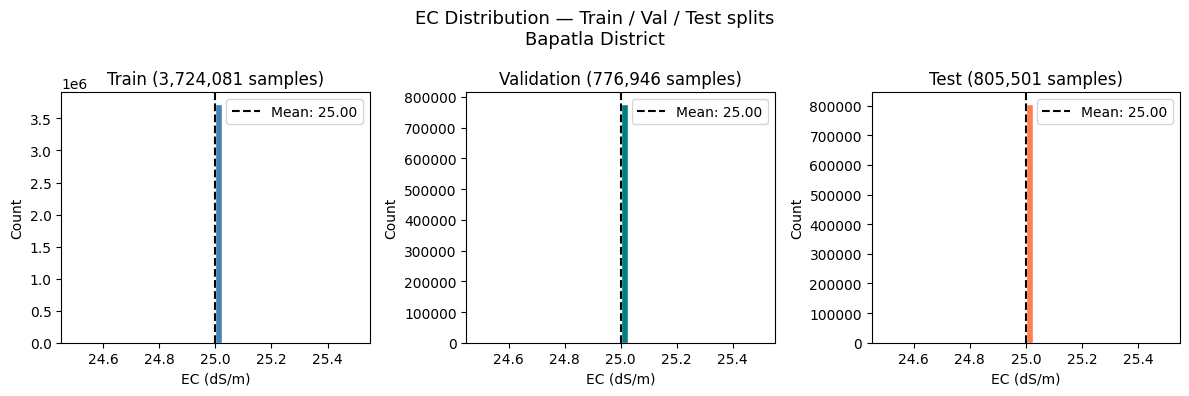


=== Dataset Summary ===
Train EC — mean: 25.000  std: 0.000
Val   EC — mean: 25.000  std: 0.000
Test  EC — mean: 25.000  std: 0.000

✓ Dataset collection COMPLETE — ready for model building!


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, y_data, label, color in zip(
    axes,
    [y_train, y_val, y_test],
    ['Train', 'Validation', 'Test'],
    ['steelblue', 'teal', 'coral']
):
    ax.hist(y_data, bins=40, color=color, edgecolor='white')
    ax.set_title(f'{label} ({len(y_data):,} samples)')
    ax.set_xlabel('EC (dS/m)')
    ax.set_ylabel('Count')
    ax.axvline(y_data.mean(), color='black', linestyle='--', label=f'Mean: {y_data.mean():.2f}')
    ax.legend()

plt.suptitle('EC Distribution — Train / Val / Test splits\nBapatla District', fontsize=13)
plt.tight_layout()
plt.savefig('/content/data/dataset_distribution.png', dpi=150)
plt.show()

print("\n=== Dataset Summary ===")
print(f"Train EC — mean: {y_train.mean():.3f}  std: {y_train.std():.3f}")
print(f"Val   EC — mean: {y_val.mean():.3f}  std: {y_val.std():.3f}")
print(f"Test  EC — mean: {y_test.mean():.3f}  std: {y_test.std():.3f}")
print("\n✓ Dataset collection COMPLETE — ready for model building!")


model training

In [ ]:
!pip install torch-geometric torch-scatter torch-sparse -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pickle, os
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.4 MB/s eta 0:00:00
ERROR: Operation cancelled by user
Device: cpu


In [ ]:
import torch
import numpy as np
import pickle
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

dataset_path = '/content/drive/MyDrive/SalinityProject/bapatla_dataset.npz'
scaler_path  = '/content/drive/MyDrive/SalinityProject/scaler.pkl'

# Load saved dataset
print(f"Loading dataset from {dataset_path}...")
data = np.load(dataset_path)

X_train_t = torch.FloatTensor(data['X_train_t'])  # [samples, 14, 5]
X_train_s = torch.FloatTensor(data['X_train_s'])  # [samples, 3]
y_train   = torch.FloatTensor(data['y_train'])

X_val_t   = torch.FloatTensor(data['X_val_t'])
X_val_s   = torch.FloatTensor(data['X_val_s'])
y_val     = torch.FloatTensor(data['y_val'])

X_test_t  = torch.FloatTensor(data['X_test_t'])
X_test_s  = torch.FloatTensor(data['X_test_s'])
y_test    = torch.FloatTensor(data['y_test'])

print("Dataset loaded successfully ✓")

# Load the scaler
print(f"Loading scaler from {scaler_path}...")
with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)
print("Scaler loaded successfully ✓")

print("=== Loaded Dataset ===")
print(f"Train : {X_train_t.shape}  labels: {y_train.shape}")
print(f"Val   : {X_val_t.shape}  labels: {y_val.shape}")
print(f"Test  : {X_test_t.shape}  labels: {y_test.shape}")
print(f"\nTemporal input : [batch, 14 years, 5 indices]")
print(f"Static input   : [batch, 3 ancillary vars]")


Mounted at /content/drive
Loading dataset from /content/drive/MyDrive/SalinityProject/bapatla_dataset.npz...
Dataset loaded successfully ✓
Loading scaler from /content/drive/MyDrive/SalinityProject/scaler.pkl...
Scaler loaded successfully ✓
=== Loaded Dataset ===
Train : torch.Size([3724081, 14, 5])  labels: torch.Size([3724081])
Val   : torch.Size([776946, 14, 5])  labels: torch.Size([776946])
Test  : torch.Size([805501, 14, 5])  labels: torch.Size([805501])

Temporal input : [batch, 14 years, 5 indices]
Static input   : [batch, 3 ancillary vars]


In [ ]:
class SalinityDataset(Dataset):
    def __init__(self, X_temporal, X_static, y):
        self.X_temporal = X_temporal
        self.X_static   = X_static
        self.y          = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X_temporal[idx],
            self.X_static[idx],
            self.y[idx]
        )

# Create dataloaders
BATCH_SIZE = 256

train_loader = DataLoader(
    SalinityDataset(X_train_t, X_train_s, y_train),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0
)
val_loader = DataLoader(
    SalinityDataset(X_val_t, X_val_s, y_val),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    SalinityDataset(X_test_t, X_test_s, y_test),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("Dataloaders ready ✓")

Train batches : 14548
Val batches   : 3035
Test batches  : 3147
Dataloaders ready ✓


In [ ]:
class AttentionLayer(nn.Module):
    """Self-attention over time steps."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        # x: [batch, seq_len, hidden_dim]
        scores  = self.attention(x)           # [batch, seq_len, 1]
        weights = torch.softmax(scores, dim=1) # [batch, seq_len, 1]
        context = (x * weights).sum(dim=1)    # [batch, hidden_dim]
        return context, weights


class CNN_BiLSTM_Attention(nn.Module):
    """
    Hybrid model:
    1. CNN    — extract spatial/spectral features from each time step
    2. BiLSTM — capture temporal trends across 15 years
    3. Attention — focus on most saline-relevant time steps
    4. FC layers — predict EC value
    """
    def __init__(self,
                 n_indices   = 5,    # NDVI, NDSI, ASTER_SI, SI1, SI2
                 n_years     = 15,   # 2010–2024
                 n_static    = 3,    # DEM, SLOPE, RAINFALL
                 cnn_filters = 64,
                 lstm_hidden = 128,
                 lstm_layers = 2,
                 dropout     = 0.3):
        super().__init__()

        # ── CNN branch: extracts features from each timestep ──
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=n_indices, out_channels=cnn_filters,
                      kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.Conv1d(cnn_filters, cnn_filters*2,
                      kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters*2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        cnn_out = cnn_filters * 2   # 128

        # ── BiLSTM branch: temporal trends ──
        self.bilstm = nn.LSTM(
            input_size   = cnn_out,
            hidden_size  = lstm_hidden,
            num_layers   = lstm_layers,
            batch_first  = True,
            bidirectional= True,
            dropout      = dropout if lstm_layers > 1 else 0
        )
        lstm_out = lstm_hidden * 2  # bidirectional → ×2 = 256

        # ── Attention layer ──
        self.attention = AttentionLayer(lstm_out)

        # ── Static feature branch ──
        self.static_fc = nn.Sequential(
            nn.Linear(n_static, 32),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ── Final regression head ──
        self.regressor = nn.Sequential(
            nn.Linear(lstm_out + 32, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x_temporal, x_static):
        # x_temporal: [batch, 15, 5]
        # x_static  : [batch, 3]

        batch_size = x_temporal.size(0)

        # CNN expects [batch, channels, length]
        # Treat each year as a position, indices as channels
        x = x_temporal.permute(0, 2, 1)        # [batch, 5, 15]
        x = self.cnn(x)                         # [batch, 128, 15]
        x = x.permute(0, 2, 1)                  # [batch, 15, 128]

        # BiLSTM
        x, _ = self.bilstm(x)                   # [batch, 15, 256]

        # Attention
        context, attn_weights = self.attention(x)  # [batch, 256]

        # Static branch
        static_feat = self.static_fc(x_static)  # [batch, 32]

        # Combine and predict
        combined = torch.cat([context, static_feat], dim=1)  # [batch, 288]
        ec_pred  = self.regressor(combined)                   # [batch, 1]

        return ec_pred.squeeze(1), attn_weights


# Instantiate model
model = CNN_BiLSTM_Attention().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture: CNN + BiLSTM + Attention")
print(f"Total parameters  : {total_params:,}")
print(f"\nModel structure:")
print(model)

Model architecture: CNN + BiLSTM + Attention
Total parameters  : 764,034

Model structure:
CNN_BiLSTM_Attention(
  (cnn): Sequential(
    (0): Conv1d(5, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
  )
  (bilstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): AttentionLayer(
    (attention): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
  )
  (static_fc): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (regressor): Sequenti

In [ ]:
# ── Hyperparameters ──
EPOCHS    = 100
LR        = 0.001
PATIENCE  = 15       # early stopping

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5,
                                                  factor=0.5)
criterion = nn.MSELoss()

# ── Training history ──
history = {'train_loss': [], 'val_loss': [], 'val_r2': []}
best_val_loss   = float('inf')
patience_counter = 0
best_model_path = '/content/data/best_model.pt'

print("Starting training...\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val R²':>8} | {'LR':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):

    # ── Training phase ──
    model.train()
    train_losses = []

    for x_t, x_s, y_batch in train_loader:
        x_t = x_t.to(device)
        x_s = x_s.to(device)
        y_b = y_batch.to(device)

        optimizer.zero_grad()
        preds, _ = model(x_t, x_s)
        loss     = criterion(preds, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    # ── Validation phase ──
    model.eval()
    val_losses = []
    val_preds  = []
    val_true   = []

    with torch.no_grad():
        for x_t, x_s, y_batch in val_loader:
            x_t  = x_t.to(device)
            x_s  = x_s.to(device)
            y_b  = y_batch.to(device)
            preds, _ = model(x_t, x_s)
            val_losses.append(criterion(preds, y_b).item())
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(y_b.cpu().numpy())

    train_loss = np.mean(train_losses)
    val_loss   = np.mean(val_losses)
    val_r2     = r2_score(val_true, val_preds)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_r2'].append(val_r2)

    scheduler.step(val_loss)

    # Print every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | "
              f"{val_r2:>8.4f} | {current_lr:>8.6f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

print("\nTraining complete ✓")
print(f"Best val loss : {best_val_loss:.4f}")
print(f"Best val R²   : {max(history['val_r2']):.4f}")

Starting training...

 Epoch | Train Loss |   Val Loss |   Val R² |       LR
-------------------------------------------------------
